# Question 2: Earring Size Calculation

Given:
- Focal length: f = 8 mm
- Pixel size: 2.2 µm × 2.2 µm
- Distance from lens to imaging plane (object distance): z = 720 mm
- Camera optical axis perpendicular to imaging plane

Task: Calculate the actual size of the earrings

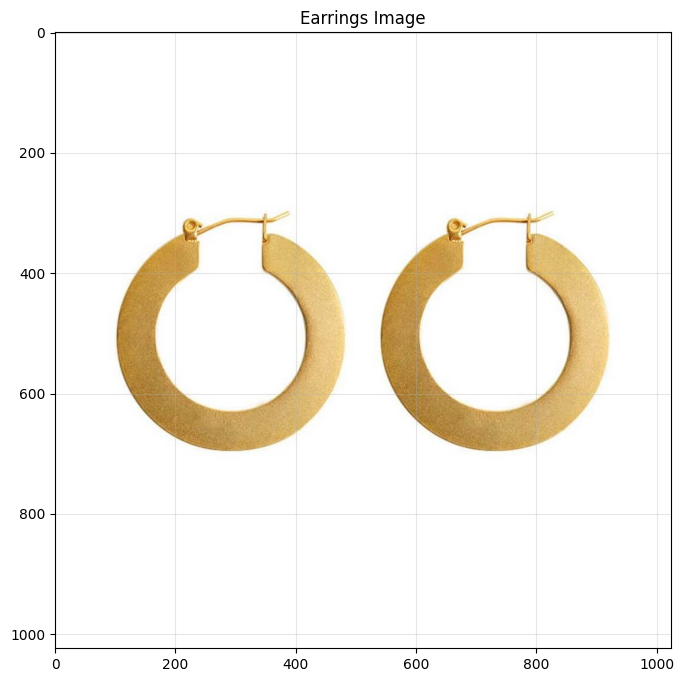

Image dimensions: 1024 × 1024 pixels


In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the earring image
img = cv2.imread('earrings.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title('Earrings Image')
plt.axis('on')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Image dimensions: {img.shape[0]} × {img.shape[1]} pixels")


## Step 1: Calculate Image Distance using Thin Lens Equation

In [5]:
# Given parameters
focal_length = 8  # mm
pixel_size = 2.2e-3  # mm (converted from 2.2 µm)
object_distance = 720  # mm (distance from lens to imaging plane/earrings)

image_distance = 1 / (1/focal_length - 1/object_distance)

print("Camera Parameters:")
print(f"Focal length (f): {focal_length} mm")
print(f"Pixel size: {pixel_size*1000:.1f} µm = {pixel_size} mm")
print(f"Object distance (d_o): {object_distance} mm")
print(f"Image distance (d_i): {image_distance:.6f} mm")


Camera Parameters:
Focal length (f): 8 mm
Pixel size: 2.2 µm = 0.0022 mm
Object distance (d_o): 720 mm
Image distance (d_i): 8.089888 mm


## Step 2: Calculate Magnification

In [6]:
# Calculate magnification
magnification = image_distance / object_distance

print(f"\nMagnification (M): {magnification:.8f}")
print(f"This means the image is {magnification:.6f} times the size of the actual object")
print(f"Or: 1 mm on the object appears as {magnification*1000:.4f} µm on the sensor")



Magnification (M): 0.01123596
This means the image is 0.011236 times the size of the actual object
Or: 1 mm on the object appears as 11.2360 µm on the sensor


## Step 3: Measure Earring Dimensions in Image

We'll detect the earrings and measure their dimensions in pixels, then convert to actual size.

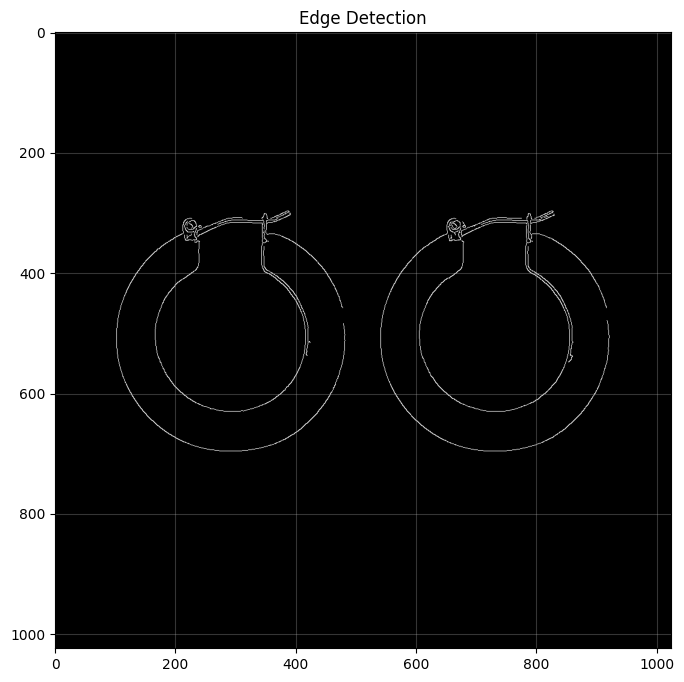

In [7]:
# Convert to grayscale for processing
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Use Canny edge detection
edges = cv2.Canny(blurred, 50, 150)

# Display edge detection result
plt.figure(figsize=(12, 8))
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')
plt.axis('on')
plt.grid(True, alpha=0.3)
plt.show()



Detected 2 circular objects

Circle details (in pixels):
Earring 1: Center=(732, 508), Radius=191 px, Diameter=382 px
Earring 2: Center=(292, 506), Radius=191 px, Diameter=382 px


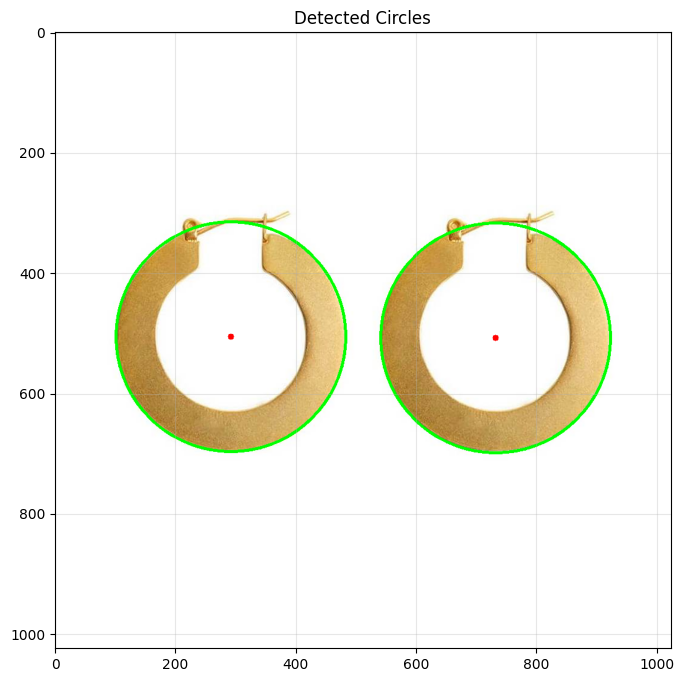

In [8]:
# Detect circles using Hough Circle Transform
circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=200,
    param1=100,
    param2=30,
    minRadius=100,
    maxRadius=400
)

# Create a copy of the image to draw on
img_with_circles = img_rgb.copy()

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    print(f"\nDetected {len(circles)} circular objects")
    print("\nCircle details (in pixels):")
    
    for i, (x, y, r) in enumerate(circles):
        # Draw the circle
        cv2.circle(img_with_circles, (x, y), r, (0, 255, 0), 3)
        # Draw the center
        cv2.circle(img_with_circles, (x, y), 5, (255, 0, 0), -1)
        
        # Calculate diameter in pixels
        diameter_pixels = 2 * r
        print(f"Earring {i+1}: Center=({x}, {y}), Radius={r} px, Diameter={diameter_pixels} px")
    
    # Display result
    plt.figure(figsize=(12, 8))
    plt.imshow(img_with_circles)
    plt.title('Detected Circles')
    plt.axis('on')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No circles detected!")


## Step 4: Calculate Actual Earring Size

Convert the measured pixel dimensions to actual physical size using:

In [9]:
if circles is not None:
    print("ACTUAL EARRING DIMENSIONS")
    
    earring_sizes = []
    
    for i, (x, y, r) in enumerate(circles):
        # Diameter in pixels
        diameter_pixels = 2 * r
        
        # Convert to size on sensor (in mm)
        diameter_on_sensor_mm = diameter_pixels * pixel_size
        
        # Convert to actual object size (in mm)
        actual_diameter_mm = diameter_on_sensor_mm / magnification
        
        earring_sizes.append(actual_diameter_mm)
        
        print(f"\nEarring {i+1}:")
        print(f"  Diameter in image: {diameter_pixels} pixels")
        print(f"  Diameter on sensor: {diameter_on_sensor_mm:.6f} mm")
        print(f"  Actual diameter: {actual_diameter_mm:.2f} mm")
        print(f"  Actual diameter: {actual_diameter_mm/10:.2f} cm")
    
    # Calculate average if multiple earrings detected
    if len(earring_sizes) > 1:
        avg_size = np.mean(earring_sizes)
        print(f"Average earring diameter: {avg_size:.2f} mm = {avg_size/10:.2f} cm")
    
else:
    print("Cannot calculate size - no circles detected")


ACTUAL EARRING DIMENSIONS

Earring 1:
  Diameter in image: 382 pixels
  Diameter on sensor: 0.840400 mm
  Actual diameter: 74.80 mm
  Actual diameter: 7.48 cm

Earring 2:
  Diameter in image: 382 pixels
  Diameter on sensor: 0.840400 mm
  Actual diameter: 74.80 mm
  Actual diameter: 7.48 cm
Average earring diameter: 74.80 mm = 7.48 cm
